# A Tactical Cash Reserve Strategy versus Dollar-Cost Averaging: Evidence from Taiwan and the United States

**Companion notebook for the manuscript** *"A tactical cash reserve strategy versus dollar-cost
averaging: evidence from Taiwan and the United States"* (submitted to the *Journal of Asset
Management*).

This notebook reproduces every number, table, and figure reported in the paper. It is organized
to follow the paper's own structure rather than a generic "exploration" order, so that each
section here corresponds directly to a section of the manuscript:

| Notebook section | Manuscript section |
|---|---|
| 1. Setup and global parameters | *Data and methodology* -- Strategy parameters (Table 1) |
| 2. Taiwan market data | *Data and methodology* -- Taiwan market data |
| 3. United States market data | *Data and methodology* -- United States market data |
| 4. Common analysis window | *Data and methodology* -- United States market data |
| 5. Backtest engine | *Data and methodology* -- Strategy parameters |
| 6. Performance metrics | *Data and methodology* -- Performance metrics |
| 7. Main results | *Results* -- Main results: strategy vs. control (Table 2, Figs. 2-3) |
| 8. Sensitivity analysis | *Results* -- Sensitivity analysis: cash-allocation ratio (Table 3, Fig. 4) |
| 9. Out-of-sample validation | *Results* -- Out-of-sample validation (Table 4) |
| 10. Robustness check | *Results* -- Robustness check: alternate correction threshold (Table 5) |
| 11. Cross-market comparison | *Results* -- Cross-market comparison and consistency (Table 6, Fig. 5) |
| 12. Parameter-leverage diagnostic | *Results* -- Additional diagnostic (Table 7, Fig. 6) |

## Design principle: one engine, two markets

The paper's central methodological claim is that the tactical strategy and the 100% dollar-cost
averaging (DCA) control are the *same* code evaluated at different settings of one parameter (the
cash-allocation ratio), and that this same code is then run, completely unmodified, on two
different markets -- Taiwan (via the Yuanta Taiwan Top 50 ETF, 0050.TW) and the United States (via
the SPDR S&P 500 ETF Trust, SPY). This notebook is written to make that claim literally true of
the code: every function defined below is market-agnostic. It takes a price series and a cash-rate
series as arguments and is called once for Taiwan and once for the United States; there is no
separate "Taiwan version" and "US version" of any function.

## How to run this notebook

1. Install dependencies: `pip install -r requirements.txt` (yfinance, pandas, numpy, scipy,
   matplotlib, openpyxl).
2. Run all cells top to bottom. Price data is cached under `data/` after the first run, so
   subsequent runs do not need a network connection.
3. Expected runtime: well under a minute (the backtest itself is a single vectorizable weekly
   loop over ~900 weeks per market; the slowest step is the one-time data download).

## Data sources

- **0050.TW** (Taiwan) and **SPY** (United States) total-return price series: Yahoo Finance, via
  the `yfinance` package, `auto_adjust=True` (dividends and splits reinvested).
- **NTD savings deposit rate**: Bank of Taiwan posted rate, via the Central Bank of Taiwan's
  historical rate table (cached at `data/twd_savings_rate.csv`).
- **USD savings deposit rate**: FDIC National Rate on Savings Deposits, stitched from two official
  sources -- the FDIC's pre-2021 archive (weekly, 2009-05-24 to 2021-03-31) and the Federal
  Reserve Bank of St. Louis's FRED series for the same rate under the FDIC's post-2021 Final Rule
  methodology (monthly, 2021-04-01 onward) -- cached at `data/usd_savings_rate.csv`.


## 1. Setup and global parameters

The block below fixes **every parameter used in the paper except the cash-allocation ratio**,
which is the sole subject of sensitivity analysis (Section "Sensitivity analysis" below). This is
the paper's central overfitting-control device: because these values are fixed here, once, before
any result is computed, no later cell in this notebook is able to "tune" them in response to how
the results turn out. The values themselves follow documented industry convention (a 15%
correction threshold is a standard definition of a market correction; a 52-week lookback is the
conventional "one-year high"; etc.) rather than being chosen to fit the data -- see the paper's
*Data and methodology* section for the full rationale.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, newton
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Fixed parameters (identical for Taiwan and the United States; see
# Table 1 in the manuscript). None of these are re-tuned anywhere below.
# ------------------------------------------------------------------
CORRECTION_THRESHOLD = 0.15      # Trigger: price down >= 15% from its trailing high
LOOKBACK_WEEKS = 52              # "Trailing high" = rolling 52-week (1-year) high
CASH_CAP_RATIO = 0.20            # Cash reserve capped at 20% of cumulative contributions
BUY_COST_RATE = 0.0015           # 0.15% transaction cost on every ETF purchase, both markets

DEFAULT_CASH_ALLOC_RATIO = 0.20        # Representative allocation ratio used in the main tables
SENSITIVITY_ALLOC_RATIOS = [0.10, 0.20, 0.30, 0.40, 0.50]   # The one parameter left open

ROBUSTNESS_THRESHOLD = 0.10      # Alternate correction threshold for the robustness check

DESIGN_PERIOD_END = "2018-12-31"     # Design (in-sample) period: ... to here
OOS_PERIOD_START = "2019-01-01"      # Out-of-sample period: here to end of data

# Nominal contribution amounts. These only scale terminal dollar values; every CAGR/MDD/Sortino/
# Cash-drag figure is a ratio and is completely unaffected by this choice.
MONTHLY_CONTRIBUTION_TWD = 10_000
WEEKLY_CONTRIBUTION_TWD = MONTHLY_CONTRIBUTION_TWD * 12 / 52
MONTHLY_CONTRIBUTION_USD = 1_000
WEEKLY_CONTRIBUTION_USD = MONTHLY_CONTRIBUTION_USD * 12 / 52

print("Global parameters set. These are not modified anywhere else in this notebook.")


Global parameters set. These are not modified anywhere else in this notebook.


## 2. Taiwan market data

The Taiwan investment vehicle is **0050.TW** (Yuanta Taiwan Top 50 ETF), the largest and most
liquid broad-market ETF on the Taiwan Stock Exchange. We download `auto_adjust=True` daily close
prices from Yahoo Finance -- this reinvests both dividends and split adjustments into the price
series, giving a total-return proxy without needing a separate dividend feed.

**A data limitation, disclosed here as it was discovered:** Yahoo Finance's history for 0050.TW
only goes back to 2 January 2009, not to the fund's actual June 2003 listing. This is why the
paper's effective sample is 2009-2026 rather than 2003-2026; see the manuscript's *Taiwan market
data* subsection for the full discussion, including why this does not include the 2008 financial
crisis and is arguably favorable to the tactical strategy's reported results.

`clean_price_series()` below detects and back-corrects any single-day jump larger than 30% in
magnitude. This is a defensive check against unannounced unit splits or vendor data-source
transitions that would otherwise register as an (illusory) 30%+ overnight gain or loss; it is not
expected to fire under normal conditions, and any correction it does make is printed so it can be
manually verified.


In [2]:
def clean_price_series(price, jump_threshold=0.30):
    '''
    Detect single-day price jumps larger than `jump_threshold` in magnitude and back-adjust
    the price series before the jump by the same ratio, so the return series is continuous.
    This guards against unannounced stock splits or vendor data transitions being misread as
    real one-day returns; genuine returns of this size essentially never occur in a broad-market
    ETF, so any correction made here should be inspected.
    '''
    price = price.copy()
    ret = price.pct_change()
    jump_dates = ret[ret.abs() > jump_threshold].index
    report = []
    for d in jump_dates:
        loc = price.index.get_loc(d)
        ratio = price.iloc[loc] / price.iloc[loc - 1]
        price.iloc[:loc] = price.iloc[:loc] * ratio
        report.append((d, ratio))
    return price, report


def fetch_total_return_price(ticker, start, cache_path, end=None, force_refresh=False):
    '''
    Download a total-return price proxy (auto-adjusted daily close) for `ticker` via yfinance,
    with local CSV caching, then apply clean_price_series(). Used identically for 0050.TW and
    SPY -- this function is market-agnostic by design (see notebook introduction).
    '''
    if (not force_refresh) and os.path.exists(cache_path):
        price = pd.read_csv(cache_path, index_col=0, parse_dates=True)["price"]
    else:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if raw.empty:
            raise RuntimeError(f"Failed to download {ticker}; check your network connection.")
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        price = close.dropna()
        price.name = "price"
        price.to_frame().to_csv(cache_path)

    price, corrections = clean_price_series(price)
    if corrections:
        print(f"[data cleaning] {ticker}: corrected {len(corrections)} anomalous jump(s):")
        for d, r in corrections:
            print(f"    {d.date()}: jump ratio {r:.4f} (back-adjusted before this date)")
    return price


TW_PRICE_CACHE = os.path.join(DATA_DIR, "0050_total_return_daily.csv")
price_daily_tw = fetch_total_return_price("0050.TW", start="2003-01-01", cache_path=TW_PRICE_CACHE)
print(f"0050.TW: {price_daily_tw.index.min().date()} to {price_daily_tw.index.max().date()}"
      f" ({len(price_daily_tw)} trading days)")
if price_daily_tw.index.min() > pd.Timestamp("2004-01-01"):
    print("[data limitation] History starts after 0050's actual 2003-06-30 listing -- "
          "see the manuscript's data-coverage disclosure.")


[data cleaning] 0050.TW: corrected 1 anomalous jump(s):
    2014-01-02: jump ratio 0.2494 (back-adjusted before this date)
0050.TW: 2009-01-02 to 2026-08-03 (4303 trading days)
[data limitation] History starts after 0050's actual 2003-06-30 listing -- see the manuscript's data-coverage disclosure.


In [3]:
def load_cash_rate_series(weekly_index, cache_path, fallback_annual_rate=0.005):
    '''
    Load a cached {date, annual_rate} savings-deposit-rate CSV and forward-fill it onto a weekly
    price index. If the cache file is missing, fall back to a flat assumed rate (documented
    simplification; savings rates move little, so this has limited effect on conclusions). Used
    identically for the TWD and USD rate series.
    '''
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, parse_dates=["date"]).set_index("date").sort_index()
        s = df["annual_rate"].reindex(weekly_index, method="ffill").bfill()
        print(f"[cash rate] loaded {cache_path}")
        return s
    print(f"[cash rate] {cache_path} not found -- falling back to a flat "
          f"{fallback_annual_rate:.2%} annual rate.")
    return pd.Series(fallback_annual_rate, index=weekly_index)


TWD_RATE_CACHE = os.path.join(DATA_DIR, "twd_savings_rate.csv")
price_weekly_tw_full = price_daily_tw.resample("W-FRI").last().dropna()
price_weekly_tw_full.name = "price"
cash_rate_weekly_tw_full = load_cash_rate_series(price_weekly_tw_full.index, TWD_RATE_CACHE)
print(f"Taiwan weekly series: {len(price_weekly_tw_full)} weeks "
      f"({len(price_weekly_tw_full) / 52:.1f} years)")


[cash rate] loaded data\twd_savings_rate.csv
Taiwan weekly series: 906 weeks (17.4 years)


## 3. United States market data

The United States investment vehicle is **SPY** (SPDR S&P 500 ETF Trust), the largest and most
heavily traded ETF globally -- the most direct United States analogue to 0050's role in Taiwan.
We reuse `fetch_total_return_price()` from the previous section unchanged.

The cash-reserve rate is the **FDIC National Rate on Savings Deposits**, an officially published
bank deposit rate (not a market-traded instrument) exactly analogous in kind to the Bank of Taiwan
rate used for the Taiwan leg. It is assembled from two official sources that together span the
full sample period without a gap (see `data/usd_savings_rate.csv`, which is the already-merged
series consumed by `load_cash_rate_series()` below):

1. **2009-05-24 to 2021-03-31** (weekly): parsed from the FDIC's historical "Prior Rule" archive
   (`data/fdic_national_rate_archive.xlsx`).
2. **2021-04-01 onward** (monthly): the FRED series for the same rate under the FDIC's Final Rule
   methodology, which took effect 1 April 2021 (FRED does not carry the pre-2021 weekly history
   under this series ID, hence the two-source stitch).

Unlike 0050, SPY's own price history goes back to 2003 -- there is no equivalent data-availability
gap on the United States side. We fetch it in full here; the next section trims it down to match
Taiwan's window for a genuinely apples-to-apples comparison.


In [4]:
US_PRICE_CACHE = os.path.join(DATA_DIR, "spy_total_return_daily.csv")
price_daily_us = fetch_total_return_price("SPY", start="2003-01-01", cache_path=US_PRICE_CACHE)
print(f"SPY: {price_daily_us.index.min().date()} to {price_daily_us.index.max().date()}"
      f" ({len(price_daily_us)} trading days)")


SPY: 2003-01-02 to 2026-08-13 (5941 trading days)


## 4. Common analysis window

"Same experimental setup" in the paper means the same *parameters* and the same *analysis
window*. Because SPY's cached history starts well before 0050's (2003 vs.\ 2009), we compute the
intersection of the two markets' available date ranges and trim **both** series to it before doing
anything else. In practice this intersection turns out to equal Taiwan's own window exactly (SPY's
range fully contains 0050's), so **this step leaves every Taiwan number in this notebook
unaffected** -- only the United States series is actually trimmed. We print a check confirming
this below.


In [5]:
common_start = max(price_daily_tw.index.min(), price_daily_us.index.min())
common_end = min(price_daily_tw.index.max(), price_daily_us.index.max())
print(f"Common analysis window: {common_start.date()} to {common_end.date()}")

tw_unaffected = (common_start == price_daily_tw.index.min()) and (common_end == price_daily_tw.index.max())
print(f"Taiwan window unaffected by the trim: {'YES' if tw_unaffected else 'NO -- CHECK THIS'}")

price_daily_us_trimmed = price_daily_us.loc[common_start:common_end]
price_weekly_us_full = price_daily_us_trimmed.resample("W-FRI").last().dropna()
price_weekly_us_full.name = "price"

USD_RATE_CACHE = os.path.join(DATA_DIR, "usd_savings_rate.csv")
cash_rate_weekly_us_full = load_cash_rate_series(price_weekly_us_full.index, USD_RATE_CACHE)
print(f"United States weekly series: {len(price_weekly_us_full)} weeks "
      f"({len(price_weekly_us_full) / 52:.1f} years)")

# Bundle each market's weekly series for convenient iteration in later sections.
MARKETS = {
    "Taiwan (0050)": dict(
        price=price_weekly_tw_full, cash_rate=cash_rate_weekly_tw_full,
        weekly_contribution=WEEKLY_CONTRIBUTION_TWD, currency="NT$",
    ),
    "United States (SPY)": dict(
        price=price_weekly_us_full, cash_rate=cash_rate_weekly_us_full,
        weekly_contribution=WEEKLY_CONTRIBUTION_USD, currency="US$",
    ),
}


Common analysis window: 2009-01-02 to 2026-08-03
Taiwan window unaffected by the trim: YES


[cash rate] loaded data\usd_savings_rate.csv
United States weekly series: 919 weeks (17.7 years)


## 5. Backtest engine

`run_backtest()` is the single function that produces every result in this paper. It is written
so that setting `alloc_ratio=0` reproduces the 100% DCA control exactly (no cash ever diverted, so
every contribution buys the ETF directly) -- the control is not a separately coded strategy, it is
this same function evaluated at the zero-allocation endpoint. This is what the paper means by
"strategy and control share identical code": any performance gap we report is attributable only to
the allocation decision, not to an implementation difference between two code paths.

**Weekly loop logic** (repeated identically for every week in the sample):

1. **Interest accrual.** The existing cash-reserve balance earns interest at that week's cash
   rate, applied as a simple `rate / 52` weekly increment to the opening balance.
2. **Contribution split.** This week's fixed contribution is split between the cash reserve
   (`alloc_ratio` share) and a direct ETF purchase, subject to the cash-reserve cap: once the
   reserve reaches `cash_cap_ratio` of cumulative contributions, any further "would-be" cash
   allocation instead goes straight into the ETF.
3. **Trigger evaluation.** We track the price's drawdown from its trailing `lookback`-week high.
   If that drawdown reaches at least `correction_threshold` **and** the strategy is currently
   "armed" (has not already deployed during this drawdown), a trigger fires and the strategy
   disarms itself -- it will not fire again until the price recovers back above the threshold,
   which re-arms it for the next correction.
4. **Deployment.** On a trigger, `deploy_fraction` of the current cash-reserve balance (1.0 = full
   lump-sum, the paper's default; see the parameter-leverage diagnostic below for `deploy_fraction
   < 1`) is transferred into the ETF alongside this week's ordinary contribution, net of the
   transaction cost.

`deploy_fraction` is not used anywhere in the main results, sensitivity analysis, out-of-sample
validation, or robustness check (all of those hold it at its default of `1.0`, matching the paper's
fixed "full lump-sum" deployment style). It exists solely so that the parameter-leverage diagnostic
(Section 12) can test what happens if deployment style itself were varied -- and it is defined here,
in the same function used everywhere else, so that experiment reuses the identical trigger/interest/
contribution logic rather than a parallel implementation.


In [6]:
def run_backtest(price, cash_rate, correction_threshold=CORRECTION_THRESHOLD,
                  lookback=LOOKBACK_WEEKS, cash_cap_ratio=CASH_CAP_RATIO,
                  alloc_ratio=0.0, buy_cost_rate=BUY_COST_RATE,
                  weekly_contribution=WEEKLY_CONTRIBUTION_TWD, deploy_fraction=1.0):
    '''
    Run the tactical cash reserve backtest (alloc_ratio=0 reproduces the 100% DCA control).

    price               : weekly closing price series (pd.Series, indexed by week-ending date)
    cash_rate           : matching weekly annualized cash-reserve interest rate series
    alloc_ratio         : fraction of each contribution diverted to the cash reserve (0-1)
    deploy_fraction     : fraction of the accumulated reserve released on each trigger
                          (1.0 = full lump-sum, the paper's default; see Section 12)

    Returns a DataFrame with one row per week.
    '''
    idx = price.index
    n = len(idx)

    rolling_high = price.rolling(window=lookback, min_periods=1).max()
    drawdown = price / rolling_high - 1.0

    equity_units = 0.0
    cash_balance = 0.0
    cumulative_contribution = 0.0
    armed = True  # False while a correction is still "in progress" and already deployed into

    records = []
    for t in range(n):
        dt = idx[t]
        p = price.iloc[t]
        wk_cash_rate = cash_rate.iloc[t]

        # 1) Interest accrual on the opening cash balance.
        cash_balance *= (1.0 + wk_cash_rate / 52.0)

        # 2) This week's contribution, split between cash reserve and direct ETF purchase,
        #    subject to the cash-reserve cap.
        cumulative_contribution += weekly_contribution
        cash_cap = cash_cap_ratio * cumulative_contribution
        to_cash = min(alloc_ratio * weekly_contribution, max(cash_cap - cash_balance, 0.0))
        to_equity_direct = weekly_contribution - to_cash
        cash_balance += to_cash

        # 3) Trigger evaluation: drawdown from the trailing high vs. the correction threshold,
        #    with the "armed/disarmed" latch that prevents repeated triggers within one correction.
        triggered = False
        if drawdown.iloc[t] <= -correction_threshold:
            if armed:
                triggered = True
                armed = False
        else:
            armed = True  # price has recovered above the threshold; re-arm for the next correction

        # 4) Deployment: release deploy_fraction of the reserve into the ETF on a trigger.
        deployed = 0.0
        if triggered and cash_balance > 0:
            deployed = cash_balance * deploy_fraction
            cash_balance -= deployed

        # Execute the ETF purchase (ordinary contribution + any deployment), net of costs.
        buy_amount = to_equity_direct + deployed
        buy_cost = buy_amount * buy_cost_rate
        net_invest = buy_amount - buy_cost
        units_bought = net_invest / p if buy_amount > 0 else 0.0
        equity_units += units_bought

        equity_value = equity_units * p
        total_value = equity_value + cash_balance

        records.append({
            "date": dt, "price": p, "contribution": weekly_contribution,
            "cumulative_contribution": cumulative_contribution,
            "to_cash": to_cash, "to_equity_direct": to_equity_direct,
            "deployed": deployed, "triggered": triggered, "buy_cost": buy_cost,
            "equity_units": equity_units, "equity_value": equity_value,
            "cash_balance": cash_balance, "total_value": total_value,
            "drawdown_from_high": drawdown.iloc[t], "rolling_high": rolling_high.iloc[t],
        })

    return pd.DataFrame(records).set_index("date")


print("run_backtest() defined -- market-agnostic; alloc_ratio=0 is the 100% DCA control.")


run_backtest() defined -- market-agnostic; alloc_ratio=0 is the 100% DCA control.


## 6. Performance metrics

Four metrics are computed identically for every backtest run in this notebook, matching the
manuscript's *Performance metrics* subsection:

- **CAGR**, via the money-weighted internal rate of return (**XIRR**) on the full weekly
  contribution schedule plus the terminal portfolio value -- i.e., the constant annualized rate
  that discounts every cash flow (contributions as outflows, terminal value as an inflow) to zero
  net present value. XIRR is used rather than a simple total-return CAGR because it correctly
  accounts for money flowing in gradually over 17 years rather than as a single lump sum.
- **MDD** (maximum drawdown), computed on the ratio of portfolio value to *cumulative
  contributions* (a "net-asset-value" proxy), rather than on portfolio value directly -- this
  isolates drawdowns caused by price declines from the purely mechanical growth in portfolio value
  that comes from continuing to contribute.
- **Sortino ratio**, $(\bar r - r_f)/\sigma_d$, computed on that same NAV-proxy series, with $r_f$
  the average cash-reserve rate over the window and $\sigma_d$ the downside deviation (using the
  full sample as the denominator, not just the negative-return weeks -- the standard definition).
- **Cash drag**, the average cash weight multiplied by the gap between the ETF's own annualized
  return and the cash rate -- the opportunity cost of holding uninvested cash, reported separately
  from the headline CAGR/MDD/Sortino comparison so that "cost of holding cash" and "benefit of
  buying dips" can be seen as distinct effects.

`compute_metrics_window()` lets us reuse a single full-sample backtest run to compute metrics for
a *sub-period* (the design period or the out-of-sample period) without re-running the backtest and
without losing the pre-period price history needed for the rolling 52-week high -- the trailing
high always uses the full history up to that date, so slicing a window never introduces
look-ahead or look-behind bias.


In [7]:
def xirr(cashflows, dates, guess=0.1):
    '''Money-weighted annualized return (Actual/365 day count), solved with a bracketed
    root-finder first and a Newton fallback for edge cases.'''
    dates = pd.to_datetime(pd.Index(dates))
    t0 = dates[0]
    days = np.array([(d - t0).days for d in dates], dtype=float)
    cfs = np.array(cashflows, dtype=float)

    def npv(r):
        return np.sum(cfs / (1.0 + r) ** (days / 365.0))

    for lo, hi in [(-0.99, 10.0), (-0.9999, 50.0)]:
        try:
            if npv(lo) * npv(hi) < 0:
                return brentq(npv, lo, hi, maxiter=1000)
        except (ValueError, OverflowError, ZeroDivisionError):
            continue
    try:
        return newton(npv, x0=guess, maxiter=1000)
    except Exception:
        return np.nan


def compute_metrics(bt, price, cash_rate, label="", initial_value=None, initial_date=None):
    '''
    Compute CAGR (XIRR), MDD, Sortino ratio, and Cash drag from a run_backtest() result.

    initial_value/initial_date: when computing metrics for a sub-period (see
    compute_metrics_window below), the portfolio value already accumulated before the window
    started is treated as a single "as-if reinvested" cash outflow at the window's start date --
    this makes the sub-period XIRR comparable to a fresh backtest starting from that value.
    '''
    dates = list(bt.index)
    cashflows = list(-bt["contribution"].values)
    if initial_value is not None:
        dates = [initial_date] + dates
        cashflows = [-initial_value] + cashflows
    dates = dates + [bt.index[-1]]
    cashflows = cashflows + [bt["total_value"].iloc[-1]]
    cagr = xirr(cashflows, dates)

    nav = bt["total_value"] / bt["cumulative_contribution"]
    running_max = nav.cummax()
    dd = nav / running_max - 1.0
    mdd = dd.min()

    nav_ret = nav.pct_change().dropna()
    mar_weekly = cash_rate.mean() / 52.0
    diff = nav_ret - mar_weekly
    downside_sq = np.where(diff < 0, diff.values ** 2, 0.0)
    downside_std_annual = np.sqrt(downside_sq.mean()) * np.sqrt(52) if len(nav_ret) else np.nan
    mean_ret_annual = nav_ret.mean() * 52 if len(nav_ret) else np.nan
    sortino = (mean_ret_annual - cash_rate.mean()) / downside_std_annual if downside_std_annual else np.nan

    n_weeks = len(price)
    equity_cagr = (price.iloc[-1] / price.iloc[0]) ** (52 / n_weeks) - 1 if n_weeks > 1 else np.nan
    cash_cagr = cash_rate.mean()
    avg_cash_weight = (bt["cash_balance"] / bt["total_value"]).mean()
    cash_drag = avg_cash_weight * (equity_cagr - cash_cagr)

    return {
        "Strategy": label, "CAGR (XIRR)": cagr, "MDD": mdd, "Sortino Ratio": sortino,
        "Cash Drag": cash_drag, "Avg. Cash Weight": avg_cash_weight,
        "Trigger Count": int(bt["triggered"].sum()),
        "Terminal Value": bt["total_value"].iloc[-1],
    }


def compute_metrics_window(bt_full, price_full, cash_rate_full, start, end, label):
    '''Slice metrics for a sub-period from an already-run full-sample backtest, without
    re-running the backtest and without losing pre-window price history for the rolling high.'''
    bt = bt_full.loc[start:end]
    price = price_full.loc[bt.index]
    cash_rate = cash_rate_full.loc[bt.index]
    loc = bt_full.index.get_loc(bt.index[0])
    if loc > 0:
        prior_date = bt_full.index[loc - 1]
        initial_value = bt_full.loc[prior_date, "total_value"]
    else:
        prior_date, initial_value = None, None
    return compute_metrics(bt, price, cash_rate, label=label,
                            initial_value=initial_value, initial_date=prior_date)


DISPLAY_COLS = ["CAGR (XIRR)", "MDD", "Sortino Ratio", "Cash Drag",
                 "Avg. Cash Weight", "Trigger Count", "Terminal Value"]

print("xirr(), compute_metrics(), compute_metrics_window() defined.")


xirr(), compute_metrics(), compute_metrics_window() defined.


## 7. Main results: strategy vs.\ control (Table 2)

We now run the backtest engine at the control setting (`alloc_ratio=0`) and the representative
tactical setting (`alloc_ratio=0.20`) for **both markets**, using the exact same call pattern for
each -- this cell is the literal implementation of "same experimental setup, two markets." The
resulting table should match the manuscript's Table 2 exactly.


In [8]:
main_results = {}   # market label -> {"control": bt, "strategy": bt}
main_metrics = {}   # market label -> {"control": metrics dict, "strategy": metrics dict}

for market, cfg in MARKETS.items():
    bt_control = run_backtest(cfg["price"], cfg["cash_rate"], alloc_ratio=0.0,
                               weekly_contribution=cfg["weekly_contribution"])
    bt_strategy = run_backtest(cfg["price"], cfg["cash_rate"], alloc_ratio=DEFAULT_CASH_ALLOC_RATIO,
                                weekly_contribution=cfg["weekly_contribution"])
    main_results[market] = {"control": bt_control, "strategy": bt_strategy}
    main_metrics[market] = {
        "control": compute_metrics(bt_control, cfg["price"], cfg["cash_rate"],
                                    label="100% DCA (control)"),
        "strategy": compute_metrics(bt_strategy, cfg["price"], cfg["cash_rate"],
                                     label=f"Tactical reserve ({DEFAULT_CASH_ALLOC_RATIO:.0%})"),
    }

rows = []
for market, m in main_metrics.items():
    for m2 in m.values():
        rows.append({"Market": market, **m2})
table2 = pd.DataFrame(rows).set_index(["Market", "Strategy"])
table2[DISPLAY_COLS]


CAGR (XIRR)     MDD  \
Market              Strategy                                      
Taiwan (0050)       100% DCA (control)           0.2007 -0.3458   
                    Tactical reserve (20%)       0.1999 -0.3441   
United States (SPY) 100% DCA (control)           0.1480 -0.3211   
                    Tactical reserve (20%)       0.1457 -0.3194   

                                            Sortino Ratio  Cash Drag  \
Market              Strategy                                           
Taiwan (0050)       100% DCA (control)             1.0742     0.0000   
                    Tactical reserve (20%)         1.1134     0.0077   
United States (SPY) 100% DCA (control)             0.8246     0.0000   
                    Tactical reserve (20%)         0.8362     0.0060   

                                            Avg. Cash Weight  Trigger Count  \
Market              Strategy                                                  
Taiwan (0050)       100% DCA (control)                0.0000             12   
                    Tactical reserve (20%)            0.0417             12   
United States (SPY) 100% DCA (control)                0.0000             13   
                    Tactical reserve (20%)            0.0417             13   

                                            Terminal Value  
Market              Strategy                                
Taiwan (0050)       100% DCA (control)     15,572,433.4948  
                    Tactical reserve (20%) 15,446,013.6808  
United States (SPY) 100% DCA (control)        904,711.4087  
                    Tactical reserve (20%)    882,597.2744

### Figures 2-3: portfolio value growth and drawdown

Figure 2 (portfolio value, log scale) and Figure 3 (underwater/drawdown chart) are each two-panel
figures -- (a) Taiwan, (b) United States -- built from the same `main_results` runs above. The
publication-quality versions used in the manuscript are produced by `figures/make_figures.py`
(included in this repository), which applies journal-specific styling; the plots below are a
lighter-weight version for interactive exploration in this notebook.


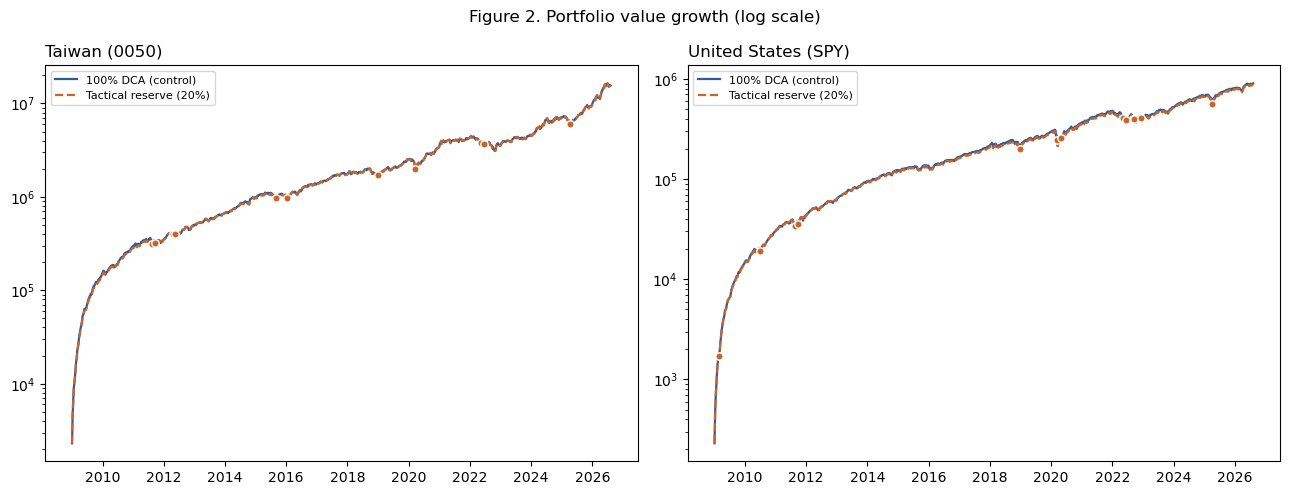

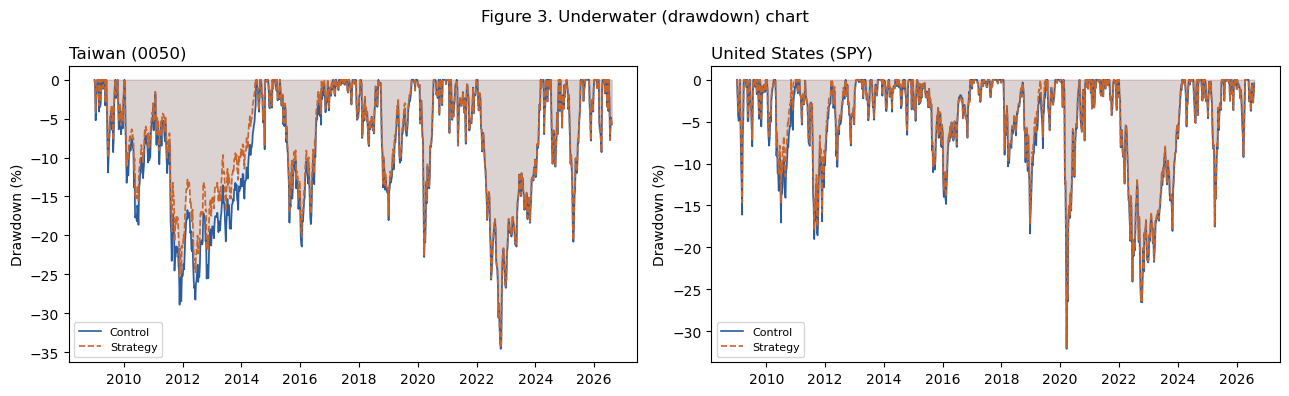

In [9]:
COLOR = {"control": "#2a5c9e", "strategy": "#c9642a"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (market, bt) in zip(axes, main_results.items()):
    ax.plot(bt["control"].index, bt["control"]["total_value"], color=COLOR["control"], lw=1.6,
            label="100% DCA (control)")
    ax.plot(bt["strategy"].index, bt["strategy"]["total_value"], color=COLOR["strategy"], lw=1.6,
            ls="--", label=f"Tactical reserve ({DEFAULT_CASH_ALLOC_RATIO:.0%})")
    trig = bt["strategy"].index[bt["strategy"]["triggered"]]
    ax.scatter(trig, bt["strategy"].loc[trig, "total_value"], color=COLOR["strategy"], s=28,
               zorder=5, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(market, loc="left")
    ax.legend(fontsize=8)
plt.suptitle("Figure 2. Portfolio value growth (log scale)")
plt.tight_layout()
plt.show()


def nav_drawdown(bt):
    nav = bt["total_value"] / bt["cumulative_contribution"]
    return nav / nav.cummax() - 1.0


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (market, bt) in zip(axes, main_results.items()):
    dd_c = nav_drawdown(bt["control"])
    dd_s = nav_drawdown(bt["strategy"])
    ax.fill_between(dd_c.index, dd_c.values * 100, 0, color=COLOR["control"], alpha=0.15)
    ax.plot(dd_c.index, dd_c.values * 100, color=COLOR["control"], lw=1.2, label="Control")
    ax.fill_between(dd_s.index, dd_s.values * 100, 0, color=COLOR["strategy"], alpha=0.15)
    ax.plot(dd_s.index, dd_s.values * 100, color=COLOR["strategy"], lw=1.2, ls="--", label="Strategy")
    ax.set_title(market, loc="left")
    ax.set_ylabel("Drawdown (%)")
    ax.legend(fontsize=8)
plt.suptitle("Figure 3. Underwater (drawdown) chart")
plt.tight_layout()
plt.show()


## 8. Sensitivity analysis: cash-allocation ratio (Table 3)

The allocation ratio is the **only** parameter this paper treats as a free variable, and the
methodological point of this section is not to find the "best" ratio but to check that performance
varies *smoothly* across it. A smooth, monotonic curve is consistent with a genuine effect; an
isolated spike at one specific ratio would be a classic overfitting warning sign (see the
manuscript's *Backtest robustness* discussion). `smoothness_check()` formalizes this: it flags any
allocation ratio whose neighboring differences change sign and are more than `tol_multiple` times
the average step size.

We run the backtest once per allocation ratio (not once per allocation ratio *per sub-period*) and
then slice out the full-sample, design-period, and out-of-sample metrics from that single run,
exactly as in Section 6 -- so the rolling 52-week high calculation never loses pre-period history.


In [10]:
def run_sensitivity_table(price, cash_rate, weekly_contribution, ratios=SENSITIVITY_ALLOC_RATIOS,
                           threshold=CORRECTION_THRESHOLD):
    rows = []
    for r in ratios:
        bt = run_backtest(price, cash_rate, correction_threshold=threshold, alloc_ratio=r,
                           weekly_contribution=weekly_contribution)
        windows = [
            ("Full sample", None, None),
            ("Design (pre-2019)", None, DESIGN_PERIOD_END),
            ("OOS (2019-)", OOS_PERIOD_START, None),
        ]
        for name, start, end in windows:
            if start is None and end is None:
                m = compute_metrics(bt, price, cash_rate, label=f"{r:.0%}")
            else:
                m = compute_metrics_window(bt, price, cash_rate, start, end, label=f"{r:.0%}")
            rows.append({"Allocation ratio": r, "Period": name, **{k: v for k, v in m.items() if k != "Strategy"}})
    return pd.DataFrame(rows)


def smoothness_check(sub_df, value_col="CAGR (XIRR)", tol_multiple=2.0):
    '''Flag an isolated spike: a point whose two neighboring steps change sign and are jointly
    more than tol_multiple times the average absolute step size across the whole curve.'''
    sub_df = sub_df.sort_values("Allocation ratio").reset_index(drop=True)
    vals = sub_df[value_col].values
    diffs = np.diff(vals)
    avg_abs_diff = np.mean(np.abs(diffs)) if len(diffs) else 0.0
    flags = []
    for i in range(1, len(vals) - 1):
        left, right = vals[i] - vals[i - 1], vals[i + 1] - vals[i]
        if np.sign(left) != np.sign(right) and (abs(left) + abs(right)) / 2 > tol_multiple * avg_abs_diff:
            flags.append(sub_df.loc[i, "Allocation ratio"])
    return flags, avg_abs_diff


sens_tables = {}
for market, cfg in MARKETS.items():
    sens_tables[market] = run_sensitivity_table(cfg["price"], cfg["cash_rate"], cfg["weekly_contribution"])
    print(f"\n=== {market}: smoothness check ===")
    for period in ["Full sample", "Design (pre-2019)", "OOS (2019-)"]:
        sub = sens_tables[market][sens_tables[market]["Period"] == period]
        flags, avg_diff = smoothness_check(sub)
        status = "no isolated spikes" if not flags else f"SUSPICIOUS: {flags}"
        print(f"  {period}: mean adjacent-step diff {avg_diff * 100:.3f} pp -- {status}")

table3 = pd.concat({
    market: sens_tables[market].pivot(index="Allocation ratio", columns="Period", values="CAGR (XIRR)")
    for market in MARKETS
}, axis=1)
table3



=== Taiwan (0050): smoothness check ===
  Full sample: mean adjacent-step diff 0.043 pp -- no isolated spikes
  Design (pre-2019): mean adjacent-step diff 0.088 pp -- no isolated spikes
  OOS (2019-): mean adjacent-step diff 0.016 pp -- no isolated spikes



=== United States (SPY): smoothness check ===
  Full sample: mean adjacent-step diff 0.090 pp -- no isolated spikes
  Design (pre-2019): mean adjacent-step diff 0.212 pp -- no isolated spikes
  OOS (2019-): mean adjacent-step diff 0.009 pp -- no isolated spikes


Taiwan (0050)                          \
Period           Design (pre-2019) Full sample OOS (2019-)   
Allocation ratio                                             
0.1000                      0.0788      0.2003      0.2949   
0.2000                      0.0780      0.1999      0.2947   
0.3000                      0.0773      0.1996      0.2946   
0.4000                      0.0765      0.1992      0.2944   
0.5000                      0.0752      0.1986      0.2942   

                 United States (SPY)                          
Period             Design (pre-2019) Full sample OOS (2019-)  
Allocation ratio                                              
0.1000                        0.1083      0.1469      0.1742  
0.2000                        0.1054      0.1457      0.1741  
0.3000                        0.1023      0.1443      0.1740  
0.4000                        0.1007      0.1437      0.1739  
0.5000                        0.0998      0.1433      0.1739

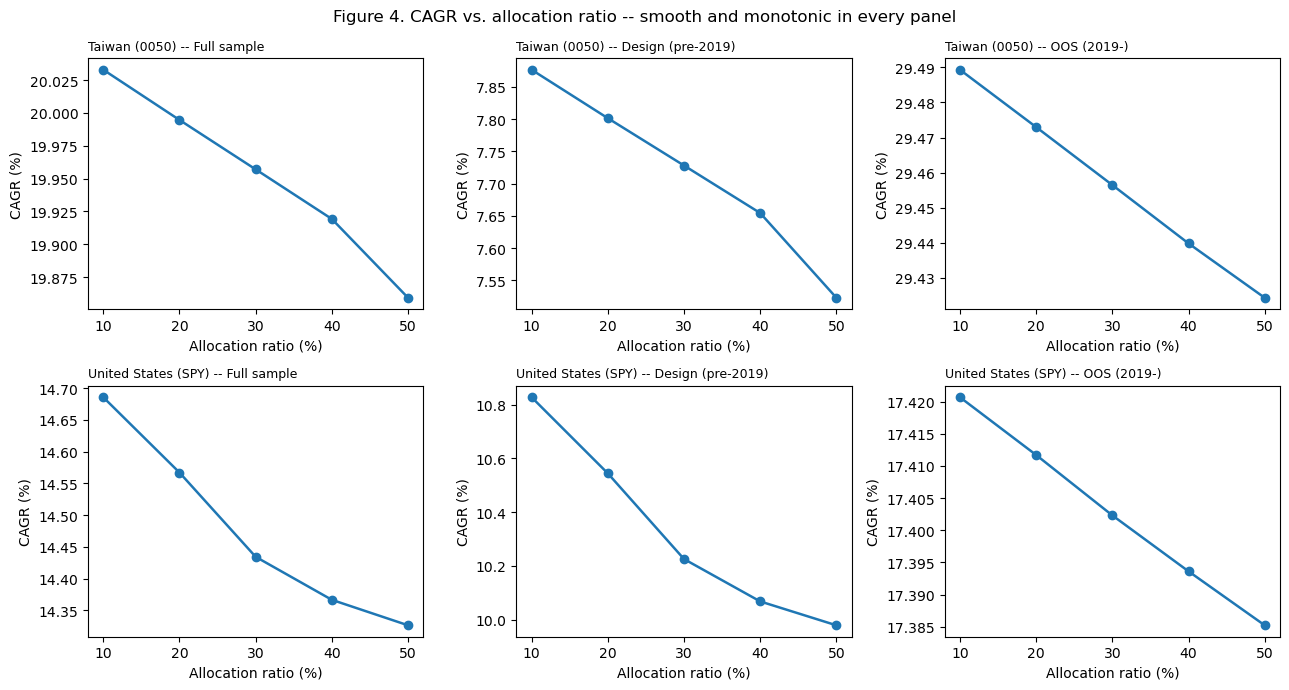

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
periods = ["Full sample", "Design (pre-2019)", "OOS (2019-)"]
for row, (market, sens) in zip(axes, sens_tables.items()):
    for ax, period in zip(row, periods):
        sub = sens[sens["Period"] == period].sort_values("Allocation ratio")
        ax.plot(sub["Allocation ratio"] * 100, sub["CAGR (XIRR)"] * 100, marker="o", lw=1.8)
        ax.set_title(f"{market} -- {period}", fontsize=9, loc="left")
        ax.set_xlabel("Allocation ratio (%)")
        ax.set_ylabel("CAGR (%)")
plt.suptitle("Figure 4. CAGR vs. allocation ratio -- smooth and monotonic in every panel")
plt.tight_layout()
plt.show()


## 9. Out-of-sample validation (Table 4)

Every fixed parameter in this paper was chosen using only the **design period** (through
2018-12-31); the **out-of-sample period** (2019-01-01 onward) was never used to select or adjust
anything. This section is therefore a genuine one-shot test, not a repeated, implicitly-overfit
split: we take the full-sample backtests already computed in Section 7 and slice out the two
sub-periods with `compute_metrics_window()`, we do not re-fit or re-run anything.


In [12]:
oos_rows = []
for market, cfg in MARKETS.items():
    bt_control = main_results[market]["control"]
    bt_strategy = main_results[market]["strategy"]
    for period_name, start, end in [("Design (pre-2019)", None, DESIGN_PERIOD_END),
                                     ("OOS (2019-)", OOS_PERIOD_START, None)]:
        m_c = compute_metrics_window(bt_control, cfg["price"], cfg["cash_rate"], start, end,
                                      label="Control")
        m_s = compute_metrics_window(bt_strategy, cfg["price"], cfg["cash_rate"], start, end,
                                      label=f"Strategy ({DEFAULT_CASH_ALLOC_RATIO:.0%})")
        oos_rows.append({"Market": market, "Period": period_name, **m_c})
        oos_rows.append({"Market": market, "Period": period_name, **m_s})

table4 = pd.DataFrame(oos_rows).set_index(["Market", "Period", "Strategy"])
table4[DISPLAY_COLS]


CAGR (XIRR)     MDD  \
Market              Period            Strategy                              
Taiwan (0050)       Design (pre-2019) Control              0.0795 -0.2891   
                                      Strategy (20%)       0.0780 -0.2534   
                    OOS (2019-)       Control              0.2951 -0.3458   
                                      Strategy (20%)       0.2947 -0.3441   
United States (SPY) Design (pre-2019) Control              0.1111 -0.1901   
                                      Strategy (20%)       0.1054 -0.1797   
                    OOS (2019-)       Control              0.1743 -0.3211   
                                      Strategy (20%)       0.1741 -0.3194   

                                                      Sortino Ratio  \
Market              Period            Strategy                        
Taiwan (0050)       Design (pre-2019) Control                0.4498   
                                      Strategy (20%)         0.4646   
                    OOS (2019-)       Control                1.9008   
                                      Strategy (20%)         1.9092   
United States (SPY) Design (pre-2019) Control                0.6421   
                                      Strategy (20%)         0.6481   
                    OOS (2019-)       Control                1.0155   
                                      Strategy (20%)         1.0246   

                                                      Cash Drag  \
Market              Period            Strategy                    
Taiwan (0050)       Design (pre-2019) Control            0.0000   
                                      Strategy (20%)     0.0077   
                    OOS (2019-)       Control            0.0000   
                                      Strategy (20%)     0.0016   
United States (SPY) Design (pre-2019) Control            0.0000   
                                      Strategy (20%)     0.0087   
                    OOS (2019-)       Control            0.0000   
                                      Strategy (20%)     0.0007   

                                                      Avg. Cash Weight  \
Market              Period            Strategy                           
Taiwan (0050)       Design (pre-2019) Control                   0.0000   
                                      Strategy (20%)            0.0692   
                    OOS (2019-)       Control                   0.0000   
                                      Strategy (20%)            0.0054   
United States (SPY) Design (pre-2019) Control                   0.0000   
                                      Strategy (20%)            0.0702   
                    OOS (2019-)       Control                   0.0000   
                                      Strategy (20%)            0.0044   

                                                      Trigger Count  \
Market              Period            Strategy                        
Taiwan (0050)       Design (pre-2019) Control                     7   
                                      Strategy (20%)              7   
                    OOS (2019-)       Control                     5   
                                      Strategy (20%)              5   
United States (SPY) Design (pre-2019) Control                     5   
                                      Strategy (20%)              5   
                    OOS (2019-)       Control                     8   
                                      Strategy (20%)              8   

                                                      Terminal Value  
Market              Period            Strategy                        
Taiwan (0050)       Design (pre-2019) Control         1,781,675.6892  
                                      Strategy (20%)  1,767,894.4477  
                    OOS (2019-)       Control        15,572,433.4948  
                                      Strategy (20%) 15,446,013.6808  
United States (SPY) Des

## 10. Robustness check: alternate correction threshold (Table 5)

Holding every other parameter fixed (including the 20% allocation ratio), we re-run the backtest
with the correction threshold changed from its main-text value of 15% to 10%, in both markets,
and check that the direction of the strategy-vs.-control gap does not flip.


In [13]:
robust_rows = []
for market, cfg in MARKETS.items():
    bt_robust = run_backtest(cfg["price"], cfg["cash_rate"], correction_threshold=ROBUSTNESS_THRESHOLD,
                              alloc_ratio=DEFAULT_CASH_ALLOC_RATIO,
                              weekly_contribution=cfg["weekly_contribution"])
    m_robust = compute_metrics(bt_robust, cfg["price"], cfg["cash_rate"],
                                label=f"Strategy ({ROBUSTNESS_THRESHOLD:.0%} threshold)")
    robust_rows.append({"Market": market, **main_metrics[market]["control"]})
    robust_rows.append({"Market": market,
                         **{**main_metrics[market]["strategy"],
                            "Strategy": f"Strategy ({CORRECTION_THRESHOLD:.0%} threshold)"}})
    robust_rows.append({"Market": market, **m_robust})

table5 = pd.DataFrame(robust_rows).set_index(["Market", "Strategy"])
table5[DISPLAY_COLS]


CAGR (XIRR)     MDD  \
Market              Strategy                                        
Taiwan (0050)       100% DCA (control)             0.2007 -0.3458   
                    Strategy (15% threshold)       0.1999 -0.3441   
                    Strategy (10% threshold)       0.1995 -0.3446   
United States (SPY) 100% DCA (control)             0.1480 -0.3211   
                    Strategy (15% threshold)       0.1457 -0.3194   
                    Strategy (10% threshold)       0.1466 -0.3201   

                                              Sortino Ratio  Cash Drag  \
Market              Strategy                                             
Taiwan (0050)       100% DCA (control)               1.0742     0.0000   
                    Strategy (15% threshold)         1.1134     0.0077   
                    Strategy (10% threshold)         1.0953     0.0050   
United States (SPY) 100% DCA (control)               0.8246     0.0000   
                    Strategy (15% threshold)         0.8362     0.0060   
                    Strategy (10% threshold)         0.8323     0.0041   

                                              Avg. Cash Weight  Trigger Count  \
Market              Strategy                                                    
Taiwan (0050)       100% DCA (control)                  0.0000             12   
                    Strategy (15% threshold)            0.0417             12   
                    Strategy (10% threshold)            0.0272             21   
United States (SPY) 100% DCA (control)                  0.0000             13   
                    Strategy (15% threshold)            0.0417             13   
                    Strategy (10% threshold)            0.0283             18   

                                              Terminal Value  
Market              Strategy                                  
Taiwan (0050)       100% DCA (control)       15,572,433.4948  
                    Strategy (15% threshold) 15,446,013.6808  
                    Strategy (10% threshold) 15,374,472.5931  
United States (SPY) 100% DCA (control)          904,711.4087  
                    Strategy (15% threshold)    882,597.2744  
                    Strategy (10% threshold)    891,247.4910

## 11. Cross-market comparison and consistency (Table 6)

This is the paper's central new contribution: bringing the four checks above together to ask
whether the strategy-vs.-control trade-off points the **same direction** in Taiwan and the United
States, at the representative 20% allocation ratio. We compute the strategy-minus-control gap for
CAGR, MDD, and Sortino ratio in each market from the metrics already computed in Section 7.


In [14]:
crossmarket_rows = []
for market in MARKETS:
    ctrl = main_metrics[market]["control"]
    strat = main_metrics[market]["strategy"]
    crossmarket_rows.append({
        "Market": market,
        "CAGR gap": strat["CAGR (XIRR)"] - ctrl["CAGR (XIRR)"],
        "MDD gap": strat["MDD"] - ctrl["MDD"],
        "Sortino ratio gap": strat["Sortino Ratio"] - ctrl["Sortino Ratio"],
    })
table6 = pd.DataFrame(crossmarket_rows).set_index("Market")
print(table6)

signs = table6.apply(np.sign)
same_direction = (signs.iloc[0] == signs.iloc[1]).all()
print(f"\nAll three metrics same direction in both markets: {'YES' if same_direction else 'NO'}")


                     CAGR gap  MDD gap  Sortino ratio gap
Market                                                   
Taiwan (0050)         -0.0008   0.0017             0.0393
United States (SPY)   -0.0024   0.0017             0.0116

All three metrics same direction in both markets: YES


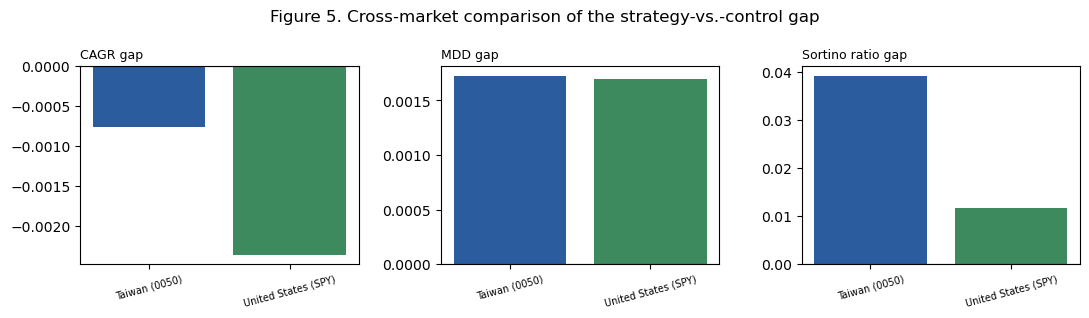

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, table6.columns):
    ax.bar(table6.index, table6[col], color=[COLOR["control"], "#3c8a5e"])
    ax.axhline(0, color="#444", lw=0.8)
    ax.set_title(col, loc="left", fontsize=9)
    ax.tick_params(axis="x", labelrotation=15, labelsize=7)
plt.suptitle("Figure 5. Cross-market comparison of the strategy-vs.-control gap")
plt.tight_layout()
plt.show()


## 12. Additional diagnostic: relative leverage of fixed parameters (Table 7)

The paper fixes four parameters ex ante (correction threshold, lookback window, cash-reserve cap,
deployment style) and treats only the allocation ratio as a sensitivity-analysis variable. This
section makes that choice auditable rather than assumed: for each fixed parameter, we vary it
alone over a plausible range (holding everything else, including the 20% allocation ratio, fixed)
and measure how far the strategy-vs.-control CAGR gap swings. A parameter with a large swing would
have been dangerous to leave open to post-hoc tuning; a parameter with almost no swing was safe to
fix by convention without materially constraining the result.

This is explicitly a **diagnostic, not a confirmatory, exercise** -- we do not use it to revise
the fixed parameters chosen in Section 1, which would violate the ex-ante design principle that
underpins every other check in this notebook. `deploy_fraction` (defined back in Section 5) exists
precisely so that "deployment style" can be tested here using the same backtest engine as
everywhere else, rather than a separate implementation.


In [16]:
def leverage_swing(price, cash_rate, weekly_contribution, control_cagr, param, grid):
    gaps = []
    for v in grid:
        kwargs = dict(alloc_ratio=DEFAULT_CASH_ALLOC_RATIO, weekly_contribution=weekly_contribution)
        kwargs[param] = v
        bt = run_backtest(price, cash_rate, **kwargs)
        m = compute_metrics(bt, price, cash_rate)
        gaps.append(m["CAGR (XIRR)"] - control_cagr)
    return max(gaps) - min(gaps)


PARAM_SPECS = [
    ("Deployment style (100%->10% of reserve)", "deploy_fraction", [1.0, 0.75, 0.50, 0.25, 0.10]),
    ("Correction threshold (5%-25%)", "correction_threshold", [0.05, 0.10, 0.15, 0.20, 0.25]),
    ("Lookback window (13-104 weeks)", "lookback", [13, 26, 52, 78, 104]),
    ("Cash reserve cap (5%-50%)", "cash_cap_ratio", [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]),
]

leverage_rows = []
for market, cfg in MARKETS.items():
    control_cagr = main_metrics[market]["control"]["CAGR (XIRR)"]
    for label, param, grid in PARAM_SPECS:
        swing = leverage_swing(cfg["price"], cfg["cash_rate"], cfg["weekly_contribution"],
                                control_cagr, param, grid)
        leverage_rows.append({"Market": market, "Parameter": label, "CAGR-gap swing (pp)": swing * 100})

table7 = pd.DataFrame(leverage_rows).set_index(["Market", "Parameter"])
table7


CAGR-gap swing (pp)
Market              Parameter                                                   
Taiwan (0050)       Deployment style (100%->10% of reserve)               0.9997
                    Correction threshold (5%-25%)                         0.9072
                    Lookback window (13-104 weeks)                        0.1127
                    Cash reserve cap (5%-50%)                             0.0017
United States (SPY) Deployment style (100%->10% of reserve)               0.8746
                    Correction threshold (5%-25%)                         0.6797
                    Lookback window (13-104 weeks)                        0.0117
                    Cash reserve cap (5%-50%)                             0.1004

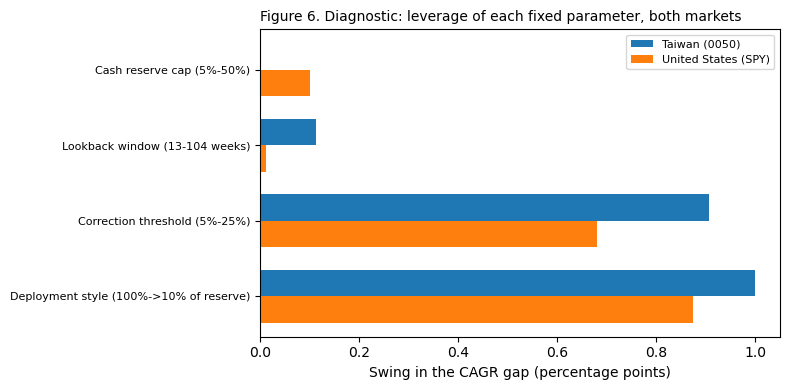

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
markets_list = list(MARKETS.keys())
params_list = [p[0] for p in PARAM_SPECS]
y = np.arange(len(params_list))
h = 0.35
for i, market in enumerate(markets_list):
    vals = [table7.loc[(market, p), "CAGR-gap swing (pp)"] for p in params_list]
    ax.barh(y + (h / 2 if i == 0 else -h / 2), vals, height=h, label=market)
ax.set_yticks(y, params_list, fontsize=8)
ax.set_xlabel("Swing in the CAGR gap (percentage points)")
ax.legend(fontsize=8)
plt.title("Figure 6. Diagnostic: leverage of each fixed parameter, both markets", loc="left", fontsize=10)
plt.tight_layout()
plt.show()


## 13. Summary

If every cell above ran without error, the tables and figures reproduced here should match
Tables 2-7 and Figures 2-6 of the manuscript exactly (Figure 1, the deployment-trigger mechanism
illustration around the March 2020 COVID-19 crash, is a static illustrative example generated by
`figures/make_figures.py` rather than a numeric result, and is not reproduced in this notebook).

**What to check if a number doesn't match:** confirm `data/` contains the cached CSV/xlsx files
committed to this repository rather than a fresh download (Yahoo Finance's history is
occasionally revised after the fact) -- delete the cache and re-run to force a fresh download if
you want to verify against current live data instead of the exact snapshot used in the paper.

**Publication-quality figures.** The vector-PDF figures embedded in the manuscript are produced by
the separate script `figures/make_figures.py` in this repository, which applies journal-specific
styling (font, color palette, print resolution) on top of the same cached data and the same
`run_backtest()` logic reproduced above -- so the manuscript's figures and this notebook's tables
are guaranteed to be numerically consistent with each other by construction, not just by
double-checking.

**License and citation.** See `LICENSE` and `README.md` in this repository.
